In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [2]:
data  = pd.read_csv("EURUSD_M15_2019-2025.csv", parse_dates = ['time'], index_col = 'time')

In [3]:
data = data[:'2022-12-31']

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 99570 entries, 2019-01-01 22:00:00 to 2022-12-30 21:45:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   99570 non-null  float64
 1   spread  99570 non-null  float64
dtypes: float64(2)
memory usage: 2.3 MB


In [5]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [6]:
window = 50

In [7]:
df = data.copy()
df["dir"] = np.where(df["returns"] > 0, 1, 0)
df["sma"] = df['price'].rolling(window).mean() - df['price'].rolling(150).mean()
df["boll"] = (df['price'] - df['price'].rolling(window).mean()) / df['price'].rolling(window).std()
df["min"] = df['price'].rolling(window).min() / df['price'] - 1
df["max"] = df['price'].rolling(window).max() / df['price'] - 1
df["mom"] = df["returns"].rolling(3).mean()
df["vol"] = df["returns"].rolling(window).std()
df.dropna(inplace = True)

In [8]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol
time,,,,,,,,,,
2019-01-03 11:15:00,1.13547,0.00014,-0.00017,0,-0.00337,-0.41014,-0.00372,0.00244,-0.00045,0.00063
2019-01-03 11:30:00,1.13498,0.00013,-0.00043,0,-0.00328,-0.76137,-0.00329,0.00287,-0.00055,0.00060
2019-01-03 11:45:00,1.13416,0.00015,-0.00072,0,-0.00320,-1.34227,-0.00257,0.00360,-0.00044,0.00061
2019-01-03 12:00:00,1.13437,0.00014,0.00019,1,-0.00310,-1.23208,-0.00275,0.00341,-0.00032,0.00061
2019-01-03 12:15:00,1.13482,0.00013,0.00040,1,-0.00295,-1.09565,-0.00099,0.00301,-0.00005,0.00054
...,...,...,...,...,...,...,...,...,...,...
2022-12-30 20:45:00,1.07055,0.00020,0.00027,1,0.00188,1.28481,-0.00528,0.00054,0.00020,0.00071
2022-12-30 21:00:00,1.07039,0.00020,-0.00015,0,0.00189,1.14211,-0.00513,0.00069,0.00003,0.00070
2022-12-30 21:15:00,1.07045,0.00018,0.00006,1,0.00190,1.13027,-0.00518,0.00064,0.00006,0.00070


In [9]:
lags = 5

In [10]:
col = []
features = ["sma", "boll", "min", "max", "mom", "vol","dir"]
for feature in features:
    for lag in range(1, lags + 1):
        col.append(f"{feature}_lag{lag}")
        df[f"{feature}_lag{lag}"] = df[feature].shift(lag)
df.dropna(inplace = True)

In [11]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-30 20:45:00,1.07055,0.00020,0.00027,1,0.00188,1.28481,-0.00528,0.00054,0.00020,0.00071,...,0.00071,0.00072,0.00073,0.00073,0.00072,0.00000,1.00000,0.00000,0.00000,1.00000
2022-12-30 21:00:00,1.07039,0.00020,-0.00015,0,0.00189,1.14211,-0.00513,0.00069,0.00003,0.00070,...,0.00071,0.00071,0.00072,0.00073,0.00073,1.00000,0.00000,1.00000,0.00000,0.00000
2022-12-30 21:15:00,1.07045,0.00018,0.00006,1,0.00190,1.13027,-0.00518,0.00064,0.00006,0.00070,...,0.00070,0.00071,0.00071,0.00072,0.00073,0.00000,1.00000,0.00000,1.00000,0.00000


In [12]:
len(col)

35

In [13]:
len(df)

99416

In [14]:
# split = int(len(df)*0.66)
# split

In [15]:
train = df.loc["2020-01-01":"2021-12-31"].copy()
train

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2020-01-01 22:00:00,1.12125,0.00100,0.00004,1,0.00134,-1.51474,-0.00029,0.00229,-0.00006,0.00029,...,0.00029,0.00030,0.00030,0.00030,0.00030,0.00000,0.00000,0.00000,0.00000,1.00000
2020-01-01 22:15:00,1.12154,0.00048,0.00026,1,0.00133,-1.11769,-0.00055,0.00203,0.00004,0.00030,...,0.00029,0.00029,0.00030,0.00030,0.00030,1.00000,0.00000,0.00000,0.00000,0.00000
2020-01-01 22:30:00,1.12152,0.00044,-0.00002,0,0.00133,-1.19651,-0.00029,0.00205,0.00010,0.00029,...,0.00030,0.00029,0.00029,0.00030,0.00030,1.00000,1.00000,0.00000,0.00000,0.00000
2020-01-01 22:45:00,1.12152,0.00039,0.00000,0,0.00132,-1.20246,-0.00029,0.00205,0.00008,0.00028,...,0.00029,0.00030,0.00029,0.00029,0.00030,0.00000,1.00000,1.00000,0.00000,0.00000
2020-01-01 23:00:00,1.12201,0.00020,0.00044,1,0.00131,-0.50025,-0.00072,0.00161,0.00014,0.00029,...,0.00028,0.00029,0.00030,0.00029,0.00029,0.00000,0.00000,1.00000,1.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 20:45:00,1.13758,0.00018,-0.00081,0,0.00232,0.87330,-0.00566,0.00092,-0.00025,0.00050,...,0.00048,0.00049,0.00049,0.00049,0.00049,1.00000,0.00000,1.00000,1.00000,0.00000
2021-12-31 21:00:00,1.13790,0.00018,0.00028,1,0.00242,0.96567,-0.00536,0.00064,-0.00013,0.00050,...,0.00050,0.00048,0.00049,0.00049,0.00049,0.00000,1.00000,0.00000,1.00000,1.00000
2021-12-31 21:15:00,1.13790,0.00016,0.00000,0,0.00250,0.92984,-0.00536,0.00064,-0.00018,0.00049,...,0.00050,0.00050,0.00048,0.00049,0.00049,1.00000,0.00000,1.00000,0.00000,1.00000


In [16]:
test = df.loc["2022-01-01":"2022-12-31"].copy()
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2022-01-02 22:00:00,1.13740,0.00100,0.00009,1,0.00263,0.63104,-0.00492,0.00108,-0.00015,0.00048,...,0.00048,0.00048,0.00049,0.00050,0.00050,0.00000,0.00000,0.00000,1.00000,0.00000
2022-01-02 22:15:00,1.13746,0.00100,0.00005,1,0.00267,0.62562,-0.00498,0.00103,-0.00011,0.00048,...,0.00048,0.00048,0.00048,0.00049,0.00050,1.00000,0.00000,0.00000,0.00000,1.00000
2022-01-02 22:30:00,1.13746,0.00071,0.00000,0,0.00271,0.59620,-0.00498,0.00103,0.00005,0.00048,...,0.00048,0.00048,0.00048,0.00048,0.00049,1.00000,1.00000,0.00000,0.00000,0.00000
2022-01-02 22:45:00,1.13748,0.00061,0.00002,1,0.00274,0.57580,-0.00499,0.00101,0.00002,0.00048,...,0.00048,0.00048,0.00048,0.00048,0.00048,0.00000,1.00000,1.00000,0.00000,0.00000
2022-01-02 23:00:00,1.13732,0.00019,-0.00014,0,0.00279,0.47696,-0.00485,0.00115,-0.00004,0.00046,...,0.00048,0.00048,0.00048,0.00048,0.00048,1.00000,0.00000,1.00000,1.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-30 20:45:00,1.07055,0.00020,0.00027,1,0.00188,1.28481,-0.00528,0.00054,0.00020,0.00071,...,0.00071,0.00072,0.00073,0.00073,0.00072,0.00000,1.00000,0.00000,0.00000,1.00000
2022-12-30 21:00:00,1.07039,0.00020,-0.00015,0,0.00189,1.14211,-0.00513,0.00069,0.00003,0.00070,...,0.00071,0.00071,0.00072,0.00073,0.00073,1.00000,0.00000,1.00000,0.00000,0.00000
2022-12-30 21:15:00,1.07045,0.00018,0.00006,1,0.00190,1.13027,-0.00518,0.00064,0.00006,0.00070,...,0.00070,0.00071,0.00071,0.00072,0.00073,0.00000,1.00000,0.00000,1.00000,0.00000


In [17]:
train[col] 

,sma_lag1,sma_lag2,sma_lag3,sma_lag4,sma_lag5,boll_lag1,boll_lag2,boll_lag3,boll_lag4,boll_lag5,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2020-01-01 22:00:00,0.00135,0.00137,0.00137,0.00137,0.00137,-1.59012,-1.34146,-1.21017,-1.16593,-0.72610,...,0.00029,0.00030,0.00030,0.00030,0.00030,0.00000,0.00000,0.00000,0.00000,1.00000
2020-01-01 22:15:00,0.00134,0.00135,0.00137,0.00137,0.00137,-1.51474,-1.59012,-1.34146,-1.21017,-1.16593,...,0.00029,0.00029,0.00030,0.00030,0.00030,1.00000,0.00000,0.00000,0.00000,0.00000
2020-01-01 22:30:00,0.00133,0.00134,0.00135,0.00137,0.00137,-1.11769,-1.51474,-1.59012,-1.34146,-1.21017,...,0.00030,0.00029,0.00029,0.00030,0.00030,1.00000,1.00000,0.00000,0.00000,0.00000
2020-01-01 22:45:00,0.00133,0.00133,0.00134,0.00135,0.00137,-1.19651,-1.11769,-1.51474,-1.59012,-1.34146,...,0.00029,0.00030,0.00029,0.00029,0.00030,0.00000,1.00000,1.00000,0.00000,0.00000
2020-01-01 23:00:00,0.00132,0.00133,0.00133,0.00134,0.00135,-1.20246,-1.19651,-1.11769,-1.51474,-1.59012,...,0.00028,0.00029,0.00030,0.00029,0.00029,0.00000,0.00000,1.00000,1.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 20:45:00,0.00224,0.00213,0.00202,0.00191,0.00181,1.26552,1.25439,1.32329,1.31638,1.32519,...,0.00048,0.00049,0.00049,0.00049,0.00049,1.00000,0.00000,1.00000,1.00000,0.00000
2021-12-31 21:00:00,0.00232,0.00224,0.00213,0.00202,0.00191,0.87330,1.26552,1.25439,1.32329,1.31638,...,0.00050,0.00048,0.00049,0.00049,0.00049,0.00000,1.00000,0.00000,1.00000,1.00000
2021-12-31 21:15:00,0.00242,0.00232,0.00224,0.00213,0.00202,0.96567,0.87330,1.26552,1.25439,1.32329,...,0.00050,0.00050,0.00048,0.00049,0.00049,1.00000,0.00000,1.00000,0.00000,1.00000


In [18]:
mu, std = train.mean(), train.std()

In [19]:
std

price       0.04247
spread      0.00010
returns     0.00045
dir         0.49998
sma         0.00226
boll        1.41770
min         0.00196
max         0.00204
mom         0.00026
vol         0.00021
sma_lag1    0.00226
sma_lag2    0.00226
sma_lag3    0.00226
sma_lag4    0.00226
sma_lag5    0.00226
boll_lag1   1.41772
boll_lag2   1.41772
boll_lag3   1.41773
boll_lag4   1.41773
boll_lag5   1.41773
min_lag1    0.00196
min_lag2    0.00196
min_lag3    0.00196
min_lag4    0.00196
min_lag5    0.00196
max_lag1    0.00204
max_lag2    0.00204
max_lag3    0.00204
max_lag4    0.00204
max_lag5    0.00204
mom_lag1    0.00026
mom_lag2    0.00026
mom_lag3    0.00026
mom_lag4    0.00026
mom_lag5    0.00026
vol_lag1    0.00021
vol_lag2    0.00021
vol_lag3    0.00021
vol_lag4    0.00021
vol_lag5    0.00021
dir_lag1    0.49998
dir_lag2    0.49998
dir_lag3    0.49998
dir_lag4    0.49998
dir_lag5    0.49998
dtype: float64

In [20]:
train_s = (train - mu) / std
train_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2020-01-01 22:00:00,-0.96428,8.05167,0.09802,1.01081,0.58991,-1.07539,0.84420,0.18843,-0.24483,-0.51781,...,-0.51567,-0.49741,-0.49148,-0.47554,-0.48566,-0.98928,-0.98928,-0.98928,-0.98924,1.01081
2020-01-01 22:15:00,-0.95745,3.07255,0.57144,1.01081,0.58606,-0.79532,0.71218,0.06159,0.17292,-0.50726,...,-0.51779,-0.51565,-0.49739,-0.49146,-0.47552,1.01081,-0.98928,-0.98928,-0.98924,-0.98928
2020-01-01 22:30:00,-0.95792,2.68954,-0.04008,-0.98928,0.58491,-0.85092,0.84879,0.07033,0.37022,-0.53379,...,-0.50724,-0.51777,-0.51563,-0.49737,-0.49145,1.01081,1.01081,-0.98928,-0.98924,-0.98928
2020-01-01 22:45:00,-0.95792,2.21078,-0.00063,-0.98928,0.57871,-0.85511,0.84879,0.07033,0.31219,-0.56957,...,-0.53378,-0.50722,-0.51775,-0.51561,-0.49735,-0.98928,1.01081,1.01081,-0.98924,-0.98928
2020-01-01 23:00:00,-0.94638,0.39148,0.96565,1.01081,0.57481,-0.35980,0.62581,-0.14384,0.54409,-0.54170,...,-0.56955,-0.53376,-0.50720,-0.51773,-0.51560,-0.98928,-0.98928,1.01081,1.01085,-0.98928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 20:45:00,-0.57978,0.19998,-1.78893,-0.98928,1.02307,0.60906,-1.89679,-0.48163,-0.96167,0.46908,...,0.38417,0.40308,0.41333,0.44393,0.44639,1.01081,-0.98928,1.01081,1.01085,-0.98928
2021-12-31 21:00:00,-0.57225,0.19998,0.62155,1.01081,1.06663,0.67422,-1.74338,-0.61939,-0.51565,0.46078,...,0.46909,0.38419,0.40309,0.41335,0.44395,-0.98928,1.01081,-0.98928,1.01085,1.01081
2021-12-31 21:15:00,-0.57225,0.00847,-0.00063,-0.98928,1.10200,0.64894,-1.74338,-0.61939,-0.68711,0.43492,...,0.46080,0.46911,0.38420,0.40311,0.41337,1.01081,-0.98928,1.01081,-0.98924,1.01081


In [21]:
train_s.describe()

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
count,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,...,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000,49893.00000
mean,-0.00000,-0.00000,0.00000,-0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,...,0.00000,-0.00000,0.00000,-0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,-0.00000
std,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
min,-2.31083,-0.56604,-15.32705,-0.98928,-5.34879,-4.36029,-7.29138,-0.93337,-13.01892,-1.48228,...,-1.48226,-1.48224,-1.48222,-1.48221,-1.48219,-0.98928,-0.98928,-0.98928,-0.98924,-0.98928
25%,-0.80958,-0.27878,-0.41227,-0.98928,-0.58786,-0.74366,-0.39044,-0.67889,-0.42028,-0.62979,...,-0.62977,-0.62975,-0.62973,-0.62971,-0.62969,-0.98928,-0.98928,-0.98928,-0.98924,-0.98928
50%,0.31588,-0.18303,-0.00063,-0.98928,-0.01213,0.00200,0.29855,-0.28492,-0.00113,-0.22343,...,-0.22342,-0.22345,-0.22348,-0.22351,-0.22351,-0.98928,-0.98928,-0.98928,-0.98924,-0.98928
75%,0.69261,-0.08728,0.42517,1.01081,0.60873,0.75505,0.71059,0.32915,0.42803,0.35681,...,0.35681,0.35664,0.35648,0.35646,0.35644,1.01081,1.01081,1.01081,1.01085,1.01081
max,1.70647,8.05167,13.35316,1.01081,3.93499,3.80372,0.99451,11.09658,12.08315,7.76017,...,7.76018,7.76019,7.76021,7.76023,7.76024,1.01081,1.01081,1.01081,1.01085,1.01081


In [22]:
from DNNModel import *

In [23]:
# fitting a DNN model with 3 Hidden Layers (50 nodes each) and dropout regularization

set_seeds(100)
model = create_model(hl = 3, hu = 50, dropout = True, input_dim = len(col))
model.fit(x = train_s[col], y = train["dir"], epochs = 50, verbose = False,
          validation_split = 0.2, shuffle = False, class_weight = cw(train))

d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.evaluate(train_s[col], train["dir"])

1560/1560 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - accuracy: 0.5263 - loss: 0.6913


[0.6913266777992249, 0.5262662172317505]

In [25]:
pred = model.predict(train_s[col])
pred

1560/1560 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step


array([[0.521365  ],
       [0.51300806],
       [0.5050131 ],
       ...,
       [0.49390858],
       [0.5325906 ],
       [0.50457674]], shape=(49893, 1), dtype=float32)

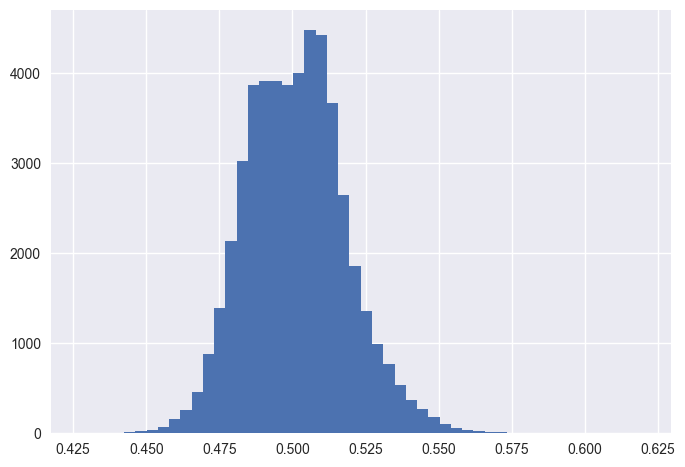

In [26]:
plt.hist(pred, bins = 50)
plt.show()

## Out-Sample Prediction and Forward Testing

In [27]:
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2022-01-02 22:00:00,1.13740,0.00100,0.00009,1,0.00263,0.63104,-0.00492,0.00108,-0.00015,0.00048,...,0.00048,0.00048,0.00049,0.00050,0.00050,0.00000,0.00000,0.00000,1.00000,0.00000
2022-01-02 22:15:00,1.13746,0.00100,0.00005,1,0.00267,0.62562,-0.00498,0.00103,-0.00011,0.00048,...,0.00048,0.00048,0.00048,0.00049,0.00050,1.00000,0.00000,0.00000,0.00000,1.00000
2022-01-02 22:30:00,1.13746,0.00071,0.00000,0,0.00271,0.59620,-0.00498,0.00103,0.00005,0.00048,...,0.00048,0.00048,0.00048,0.00048,0.00049,1.00000,1.00000,0.00000,0.00000,0.00000
2022-01-02 22:45:00,1.13748,0.00061,0.00002,1,0.00274,0.57580,-0.00499,0.00101,0.00002,0.00048,...,0.00048,0.00048,0.00048,0.00048,0.00048,0.00000,1.00000,1.00000,0.00000,0.00000
2022-01-02 23:00:00,1.13732,0.00019,-0.00014,0,0.00279,0.47696,-0.00485,0.00115,-0.00004,0.00046,...,0.00048,0.00048,0.00048,0.00048,0.00048,1.00000,0.00000,1.00000,1.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-30 20:45:00,1.07055,0.00020,0.00027,1,0.00188,1.28481,-0.00528,0.00054,0.00020,0.00071,...,0.00071,0.00072,0.00073,0.00073,0.00072,0.00000,1.00000,0.00000,0.00000,1.00000
2022-12-30 21:00:00,1.07039,0.00020,-0.00015,0,0.00189,1.14211,-0.00513,0.00069,0.00003,0.00070,...,0.00071,0.00071,0.00072,0.00073,0.00073,1.00000,0.00000,1.00000,0.00000,0.00000
2022-12-30 21:15:00,1.07045,0.00018,0.00006,1,0.00190,1.13027,-0.00518,0.00064,0.00006,0.00070,...,0.00070,0.00071,0.00071,0.00072,0.00073,0.00000,1.00000,0.00000,1.00000,0.00000


In [28]:
test_s = (test - mu) / std
test_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2022-01-02 22:00:00,-0.58402,8.05167,0.19387,1.01081,1.15843,0.43817,-1.52006,-0.40410,-0.57306,0.39499,...,0.39503,0.38898,0.43498,0.46086,0.46917,-0.98928,-0.98928,-0.98928,1.01085,-0.98928
2022-01-02 22:15:00,-0.58261,8.05167,0.11606,1.01081,1.17773,0.43435,-1.54687,-0.42995,-0.41292,0.35987,...,0.39500,0.39505,0.38900,0.43499,0.46088,1.01081,-0.98928,-0.98928,-0.98924,1.01081
2022-01-02 22:30:00,-0.58261,5.27485,-0.00063,-0.98928,1.19427,0.41361,-1.54687,-0.42995,0.18193,0.35268,...,0.35989,0.39502,0.39507,0.38902,0.43501,1.01081,1.01081,-0.98928,-0.98924,-0.98928
2022-01-02 22:45:00,-0.58214,4.31733,0.03826,1.01081,1.20846,0.39921,-1.55581,-0.43856,0.09039,0.35251,...,0.35269,0.35990,0.39504,0.39509,0.38904,-0.98928,1.01081,1.01081,-0.98924,-0.98928
2022-01-02 23:00:00,-0.58590,0.29573,-0.31182,-0.98928,1.22949,0.32950,-1.48432,-0.36964,-0.16131,0.29914,...,0.35252,0.35271,0.35992,0.39506,0.39511,1.01081,-0.98928,1.01081,1.01085,-0.98928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-30 20:45:00,-2.15802,0.39148,0.59869,1.01081,0.82782,0.89933,-1.70094,-0.66821,0.76489,1.48767,...,1.48812,1.53023,1.55790,1.55616,1.54238,-0.98928,1.01081,-0.98928,-0.98924,1.01081
2022-12-30 21:00:00,-2.16179,0.39148,-0.33127,-0.98928,0.83353,0.79867,-1.62500,-0.59501,0.10829,1.44521,...,1.48768,1.48814,1.53024,1.55792,1.55618,1.01081,-0.98928,1.01081,-0.98924,-0.98928
2022-12-30 21:15:00,-2.16038,0.19998,0.12336,1.01081,0.83908,0.79032,-1.65348,-0.62247,0.22987,1.44340,...,1.44522,1.48770,1.48815,1.53026,1.55794,-0.98928,1.01081,-0.98928,1.01085,-0.98928


In [29]:
model.evaluate(test_s[col], test["dir"])

777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step - accuracy: 0.5204 - loss: 0.6924


[0.6924065351486206, 0.5203510522842407]

In [30]:
pred = model.predict(train_s[col])
pred

1560/1560 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step


array([[0.521365  ],
       [0.51300806],
       [0.5050131 ],
       ...,
       [0.49390858],
       [0.5325906 ],
       [0.50457674]], shape=(49893, 1), dtype=float32)

(array([1.000e+00, 0.000e+00, 0.000e+00, 7.000e+00, 9.000e+00, 2.200e+01,
        3.500e+01, 7.300e+01, 1.560e+02, 2.580e+02, 4.560e+02, 8.760e+02,
        1.396e+03, 2.142e+03, 3.026e+03, 3.865e+03, 3.920e+03, 3.912e+03,
        3.868e+03, 4.007e+03, 4.482e+03, 4.426e+03, 3.668e+03, 2.652e+03,
        1.863e+03, 1.361e+03, 9.920e+02, 7.690e+02, 5.380e+02, 3.740e+02,
        2.690e+02, 1.860e+02, 1.050e+02, 6.100e+01, 4.100e+01, 2.600e+01,
        9.000e+00, 1.500e+01, 6.000e+00, 3.000e+00, 3.000e+00, 2.000e+00,
        2.000e+00, 3.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 4.000e+00]),
 array([0.42695683, 0.43081209, 0.43466735, 0.43852264, 0.4423779 ,
        0.44623315, 0.45008841, 0.4539437 , 0.45779896, 0.46165422,
        0.46550947, 0.46936476, 0.47322002, 0.47707528, 0.48093054,
        0.48478583, 0.48864108, 0.49249634, 0.4963516 , 0.50020689,
        0.50406212, 0.5079174 , 0.51177269, 0.51562792, 0.51948321,
        0.52333844, 0.52719373, 0.53

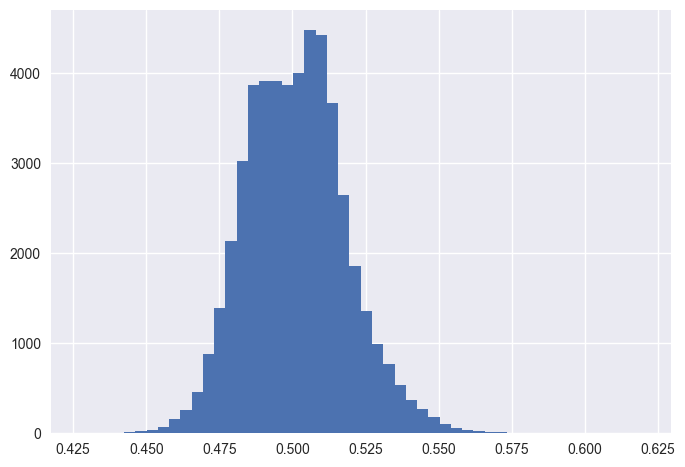

In [31]:
plt.hist(pred, bins = 50)

In [32]:
test['proba'] = model.predict(test_s[col])  

777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step


In [33]:
test["position"] = np.where(test.proba < 0.47, -1, np.nan) # 1. short where proba < 0.47

In [34]:
test["position"] = np.where(test.proba > 0.53, 1, test.position) # 2. long where proba > 0.53

In [35]:
test["hour"] = test.index.hour

In [36]:
test["position"] = np.where(~test.hour.between(12, 16), 0, test.position) # 3. neutral in non-busy hours

In [37]:
test["position"] = test.position.ffill().fillna(0) # 4. in all other cases: hold position

In [38]:
test.position.value_counts(dropna = False)

position
0.00000     21409
1.00000      2515
-1.00000      915
Name: count, dtype: int64

In [39]:
test["strategy"] = test["position"] * test["returns"]

In [40]:
test["creturns"] = test["returns"].cumsum().apply(np.exp)
test["cstrategy"] = test["strategy"].cumsum().apply(np.exp)

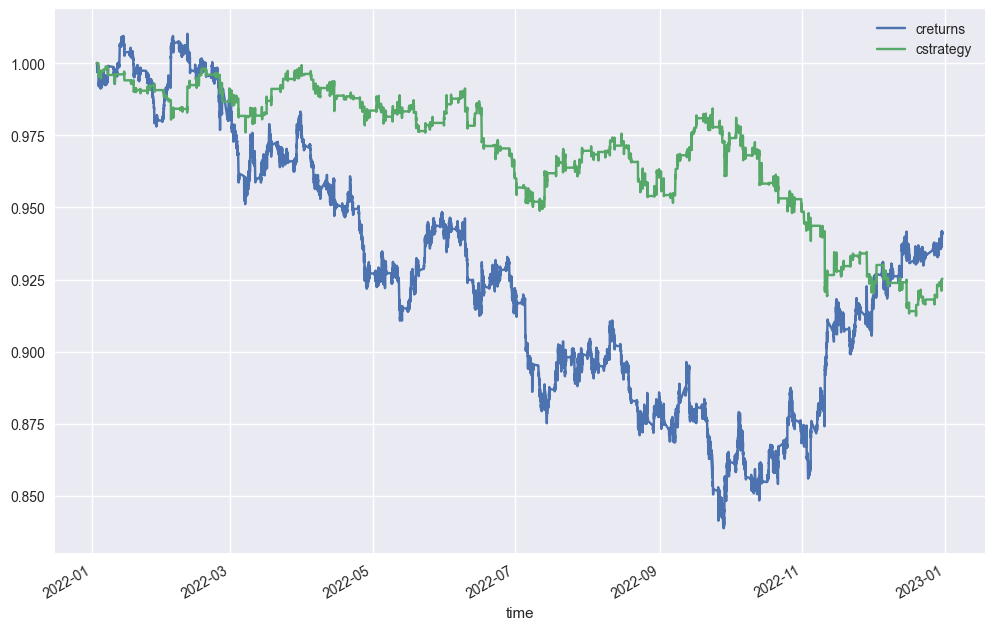

In [41]:
test[["creturns", "cstrategy"]].plot(figsize = (12, 8))
plt.show()

In [42]:
ptc = 0.00005 

In [43]:
test['trades'] = test.position.diff().abs()

In [44]:
test['trades'].value_counts()

trades
0.00000    24292
1.00000      458
2.00000       88
Name: count, dtype: int64

In [45]:
test['strategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

In [46]:
test['cstrategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

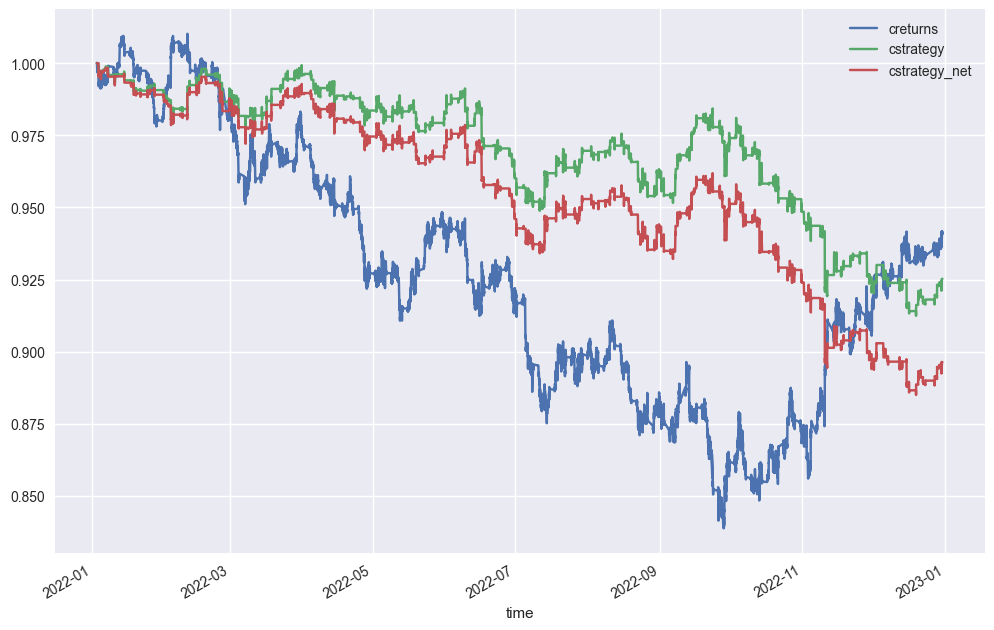

In [47]:
test[['creturns', 'cstrategy', 'cstrategy_net']].plot(figsize = (12, 8))
plt.show()


## XAI Decision Filtering Gate (SHAP)

This section adds a **risk-management gate** in front of the DNN’s trade decisions.

- The DNN produces a position signal (`test["position"]`) at every timestamp.
- A trade only happens when the position **changes** (captured by `test["trades"]`).
- The XAI gate runs **only at trade events** and uses **local SHAP feature importance** to decide whether a *new entry* is sufficiently well-explained.
- **Exits are always allowed** (reduces risk); **entries are filtered** (reduces low-quality / weakly-explained trades).

Outcome: we get a new position series `test["position_xai"]` and a net equity curve `test["cstrategy_net_xai"]` to compare against the baseline `test["cstrategy_net"]`.

In [48]:
# If needed:
# !pip install shap

import shap

# Gate hyperparameters (tune these)
TOP_N = 3
N_BACKGROUND = 200         # SHAP background sample size
N_CALIB = 800             # number of entry/flip events used to calibrate threshold
SHAP_QUANTILE = 0.60      # keep only the strongest ~25% explanations (higher => fewer trades)
PROBA_MARGIN = 0      # additional confidence margin around 0.5 for allowing entries
EXCLUDE_TOP1_PREFIXES = ("dir_",)  # treat these as weak/less-informative top drivers


# Build SHAP explainer on training distribution
background = train_s[col].sample(N_BACKGROUND, random_state=42).values
explainer = shap.DeepExplainer(model, background)


def _extract_shap_vector(shap_values):
    """Return a 1D SHAP vector for the (single) model output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr).reshape(-1)


def _top_shap_summary(instance_1d, *, top_n=TOP_N):
    """Compute local SHAP summary for one instance."""
    instance_2d = instance_1d.reshape(1, -1)
    shap_values = explainer.shap_values(instance_2d, check_additivity=False)
    sv = _extract_shap_vector(shap_values)

    abs_sv = np.abs(sv)
    top_idx = np.argsort(abs_sv)[::-1][:top_n]
    top_features = [col[int(i)] for i in top_idx]
    top_shap = sv[top_idx]

    return {
        "sv": sv,
        "sv_sum": float(sv.sum()),
        "top_idx": top_idx,
        "top_features": top_features,
        "top_shap": [float(x) for x in top_shap],
        "top_abs": [float(x) for x in abs_sv[top_idx]],
        "top1_abs": float(abs_sv[top_idx[0]]),
    }


def calibrate_shap_threshold(test_df, test_scaled, *, quantile=SHAP_QUANTILE, n_calib=N_CALIB):
    """
    Calibrate an absolute-SHAP threshold from the distribution of top-1 SHAP magnitudes
    on (a sample of) entry/flip events.

    Higher threshold => fewer trades (stricter risk filter).
    """
    # Events where the baseline strategy changes position AND desires a non-zero position
    trade_event = test_df["trades"].fillna(0) > 0
    entry_like = trade_event & (test_df["position"].fillna(0) != 0)
    event_idx = test_df.index[entry_like]

    if len(event_idx) == 0:
        return 0.0

    # Sample for speed
    if len(event_idx) > n_calib:
        event_idx = event_idx[:n_calib]

    top1_abs_list = []
    for idx in event_idx:
        instance = test_scaled.loc[idx, col].values
        summ = _top_shap_summary(instance, top_n=TOP_N)
        top1_abs_list.append(summ["top1_abs"])

    thr = float(np.quantile(np.array(top1_abs_list), quantile))
    return thr


def xai_gate_entry(instance_1d, desired_pos, proba, *, shap_threshold, top_n=TOP_N):
    """
    Decide whether to ALLOW a *new entry* (desired_pos in {-1, +1}) based on local SHAP.

    Checks:
    - confidence: proba must be far enough from 0.5 (PROBA_MARGIN)
    - explanation strength: top-1 |SHAP| must exceed calibrated shap_threshold
    - explanation direction: sum(SHAP) should align with desired direction
    - explanation quality: avoid trivial top driver(s) like dir_lag* (optional)

    Returns: allow(bool), info(dict)
    """
    desired_pos = int(desired_pos)
    proba = float(proba)

    # Confidence check (acts like a second-stage filter)
    if desired_pos == 1:
        proba_ok = proba >= (0.5 + PROBA_MARGIN)
    else:
        proba_ok = proba <= (0.5 - PROBA_MARGIN)

    summ = _top_shap_summary(instance_1d, top_n=top_n)
    sv_sum = summ["sv_sum"]

    direction_ok = (desired_pos == 1 and sv_sum > 0) or (desired_pos == -1 and sv_sum < 0)
    magnitude_ok = summ["top1_abs"] >= float(shap_threshold)

    top1 = summ["top_features"][0]
    top1_ok = not any(top1.startswith(p) for p in EXCLUDE_TOP1_PREFIXES)

    allow = bool(proba_ok and direction_ok and magnitude_ok and top1_ok)

    info = {
        "proba": proba,
        "desired_pos": desired_pos,
        "sv_sum": sv_sum,
        "top_features": summ["top_features"],
        "top_shap": summ["top_shap"],
        "top_abs": summ["top_abs"],
        "top1_abs": summ["top1_abs"],
        "proba_ok": bool(proba_ok),
        "direction_ok": bool(direction_ok),
        "magnitude_ok": bool(magnitude_ok),
        "top1_ok": bool(top1_ok),
        "shap_threshold": float(shap_threshold),
    }
    return allow, info


def format_gate_explanation(prev_pos, desired_pos, final_pos, info, allow):
    tf = info.get("top_features", [])
    ts = info.get("top_shap", [])
    parts = [
        f"prev={prev_pos}, desired={desired_pos}, final={final_pos}",
        f"proba={info.get('proba', np.nan):.3f}, shap_sum={info.get('sv_sum', np.nan):+.4f}, top1_abs={info.get('top1_abs', np.nan):.4f}",
        f"shap_threshold={info.get('shap_threshold', np.nan):.4f}",
        "top features: " + ", ".join([f"{f}({v:+.4f})" for f, v in zip(tf, ts)]),
        f"checks: proba={info.get('proba_ok')} direction={info.get('direction_ok')} magnitude={info.get('magnitude_ok')} top1_ok={info.get('top1_ok')}",
        "DECISION: " + ("ALLOW" if allow else "DENY"),
    ]
    return "\n".join(parts)

d:\anaconda3\envs\mlops_test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\anaconda3\envs\mlops_test\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 35))']
  warnings.warn(msg)


In [49]:
# Apply XAI gate only when the baseline strategy would trade
pos_target = test["position"].copy()

# ---------------------------
# FIX FOR DATA LEAKAGE / SNOOPING
# ---------------------------
# DO NOT calibrate SHAP threshold on the test set.
# Instead, calibrate on a "calibration" slice taken from the training period.
# This keeps the test year purely out-of-sample for the XAI gate evaluation.

CALIB_FRAC = 0.20  # last 20% of train used for calibration
calib_start = int(len(train) * (1 - CALIB_FRAC))
calib = train.iloc[calib_start:].copy()
calib_s = (calib - mu) / std

# Build baseline signals on calibration slice (same rules as test baseline)
PROBA_SHORT = 0.47
PROBA_LONG = 0.53
BUSY_HOUR_START = 12
BUSY_HOUR_END = 16

calib["proba"] = model.predict(calib_s[col])
calib["position"] = np.where(calib.proba < PROBA_SHORT, -1, np.nan)
calib["position"] = np.where(calib.proba > PROBA_LONG, 1, calib.position)
calib["hour"] = calib.index.hour
calib["position"] = np.where(~calib.hour.between(BUSY_HOUR_START, BUSY_HOUR_END), 0, calib.position)
calib["position"] = calib.position.ffill().fillna(0)
calib["trades"] = calib.position.diff().abs().fillna(0)

# Calibrate SHAP threshold from entry/flip events in CALIBRATION slice (not test)
SHAP_THRESHOLD = calibrate_shap_threshold(calib, calib_s, quantile=SHAP_QUANTILE, n_calib=N_CALIB)
print("Calibrated SHAP_THRESHOLD (from TRAIN calibration slice):", SHAP_THRESHOLD)

# Construct position_xai sequentially:
# - Exits to 0 are always allowed
# - Entries to +/-1 are filtered by SHAP + confidence checks
# - Flips become: exit (allowed) then optional entry (gated)

position_xai = pd.Series(index=test.index, dtype=float)
position_xai.iloc[0] = float(pos_target.iloc[0])

trade_event = test["trades"].fillna(0) > 0

gate_log = []

for i in range(1, len(test)):
    idx = test.index[i]
    prev = float(position_xai.iloc[i - 1])
    desired = float(pos_target.iloc[i])

    # Default: hold
    final_pos = prev
    action = "hold"
    allow = True

    proba = float(test.loc[idx, "proba"])
    info = {"proba": proba, "desired_pos": int(desired), "sv_sum": np.nan, "top_features": [], "top_shap": [], "top_abs": [], "top1_abs": np.nan, "proba_ok": True, "direction_ok": True, "magnitude_ok": True, "top1_ok": True, "shap_threshold": float(SHAP_THRESHOLD)}

    if trade_event.iloc[i]:
        # Model wants to change position here
        if desired == 0:
            action = "exit"
            final_pos = 0.0
            allow = True

        elif prev != 0 and np.sign(prev) != np.sign(desired):
            # Flip: always exit; entry is gated
            action = "flip"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else 0.0

        else:
            # Entry from flat, or re-entry after being flat
            action = "entry"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else prev

    position_xai.iloc[i] = final_pos

    if trade_event.iloc[i]:
        gate_log.append({
            "time": idx,
            "action": action,
            "prev_pos": prev,
            "desired_pos": desired,
            "final_pos": final_pos,
            "allow": bool(allow),
            "proba": info.get("proba", np.nan),
            "sv_sum": info.get("sv_sum", np.nan),
            "top1": info.get("top_features", [None])[0] if info.get("top_features") else None,
            "top1_abs": info.get("top1_abs", np.nan),
            "top1_shap": info.get("top_shap", [np.nan])[0] if info.get("top_shap") else np.nan,
            "proba_ok": info.get("proba_ok", True),
            "direction_ok": info.get("direction_ok", True),
            "magnitude_ok": info.get("magnitude_ok", True),
            "top1_ok": info.get("top1_ok", True),
            "shap_threshold": info.get("shap_threshold", np.nan),
            "explanation": format_gate_explanation(prev, desired, final_pos, info, allow),
        })

# Attach to test
position_xai = position_xai.ffill().fillna(0)
test["position_xai"] = position_xai

# Trades and performance with gate
test["trades_xai"] = test["position_xai"].diff().abs().fillna(0)
test["strategy_xai"] = test["position_xai"] * test["returns"]
test["cstrategy_xai"] = test["strategy_xai"].cumsum().apply(np.exp)
test["cstrategy_net_xai"] = (test["strategy_xai"] - test["trades_xai"] * ptc).cumsum().apply(np.exp)

# Gate log table
gate_log_df = pd.DataFrame(gate_log).set_index("time")
gate_log_df.head()

312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step


d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(400, 35))']
  warnings.warn(msg)


Calibrated SHAP_THRESHOLD (from TRAIN calibration slice): 0.010626289249505158


,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_abs,top1_shap,proba_ok,direction_ok,magnitude_ok,top1_ok,shap_threshold,explanation
time,,,,,,,,,,,,,,,,
2022-01-03 14:15:00,entry,0.00000,1.00000,1.00000,True,0.53831,0.03747,mom_lag1,0.01971,0.01971,True,True,True,True,0.01063,"prev=0.0, desired=1.0, final=1.0\nproba=0.538,..."
2022-01-03 17:00:00,exit,1.00000,0.00000,0.00000,True,0.52007,NaN,None,NaN,NaN,True,True,True,True,0.01063,"prev=1.0, desired=0.0, final=0.0\nproba=0.520,..."
2022-01-04 12:00:00,entry,0.00000,1.00000,1.00000,True,0.53202,0.03118,mom_lag1,0.01244,0.01244,True,True,True,True,0.01063,"prev=0.0, desired=1.0, final=1.0\nproba=0.532,..."
2022-01-04 15:15:00,flip,1.00000,-1.00000,0.00000,False,0.46416,-0.03668,dir_lag1,0.00700,-0.00700,True,True,False,False,0.01063,"prev=1.0, desired=-1.0, final=0.0\nproba=0.464..."
2022-01-04 17:00:00,exit,0.00000,0.00000,0.00000,True,0.49693,NaN,None,NaN,NaN,True,True,True,True,0.01063,"prev=0.0, desired=0.0, final=0.0\nproba=0.497,..."


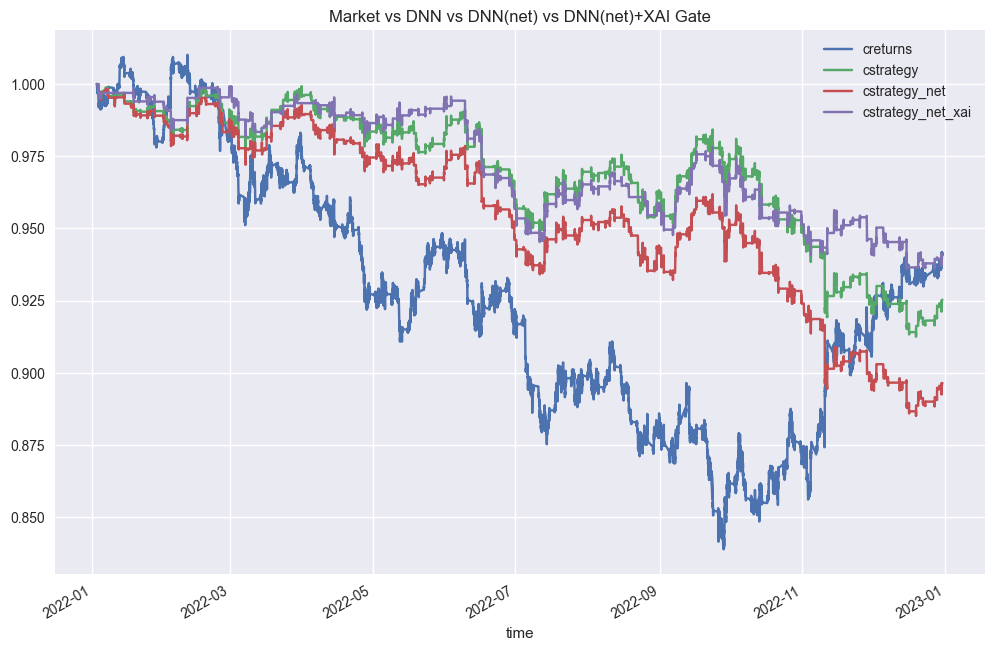

Baseline (net) ending value: 0.8964041305317537
XAI-gated (net) ending value: 0.9411664310936856
Baseline orders (sum abs pos change): 634.0
XAI orders (sum abs pos change): 426.0
Baseline trade events (bars with orders): 546
XAI trade events (bars with orders): 390
Gate evaluated events: 546
Gate allowed events: 442
Gate denied events: 104
Order reduction vs baseline: 32.81%


In [50]:
# Compare baseline vs XAI-gated strategy (net of trading costs)
compare_cols = ["creturns", "cstrategy", "cstrategy_net", "cstrategy_net_xai"]
test[compare_cols].plot(figsize=(12, 8))
plt.title("Market vs DNN vs DNN(net) vs DNN(net)+XAI Gate")
plt.show()

# Trade counts and gate stats
baseline_orders = float(test["trades"].fillna(0).sum())
xai_orders = float(test["trades_xai"].fillna(0).sum())
baseline_trade_events = int((test["trades"].fillna(0) > 0).sum())
xai_trade_events = int((test["trades_xai"].fillna(0) > 0).sum())

allowed = int(gate_log_df["allow"].sum())
denied = int((~gate_log_df["allow"]).sum())

print("Baseline (net) ending value:", float(test["cstrategy_net"].iloc[-1]))
print("XAI-gated (net) ending value:", float(test["cstrategy_net_xai"].iloc[-1]))
print("Baseline orders (sum abs pos change):", baseline_orders)
print("XAI orders (sum abs pos change):", xai_orders)
print("Baseline trade events (bars with orders):", baseline_trade_events)
print("XAI trade events (bars with orders):", xai_trade_events)
print("Gate evaluated events:", len(gate_log_df))
print("Gate allowed events:", allowed)
print("Gate denied events:", denied)

# How XAI acts as risk management
reduction = 0 if baseline_orders == 0 else 1 - (xai_orders / baseline_orders)
print("Order reduction vs baseline:", f"{reduction:.2%}")

In [51]:
# Show sample trade decisions with explanations

# Sample a few allowed and denied events (if available)
allowed_samples = gate_log_df[gate_log_df["allow"]].head(5)
denied_samples = gate_log_df[~gate_log_df["allow"]].head(5)

print("\n--- Sample ALLOWED decisions (first 5) ---")
for t, row in allowed_samples.iterrows():
    print("\nTime:", t)
    print(row["explanation"])

print("\n--- Sample DENIED decisions (first 5) ---")
for t, row in denied_samples.iterrows():
    print("\nTime:", t)
    
    print(row["explanation"])

# Compact table view
cols_view = ["action", "prev_pos", "desired_pos", "final_pos", "allow", "proba", "sv_sum", "top1", "top1_shap"]
gate_log_df[cols_view].head(20)


--- Sample ALLOWED decisions (first 5) ---

Time: 2022-01-03 14:15:00
prev=0.0, desired=1.0, final=1.0
proba=0.538, shap_sum=+0.0375, top1_abs=0.0197
shap_threshold=0.0106
top features: mom_lag1(+0.0197), dir_lag1(+0.0063), dir_lag5(+0.0054)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2022-01-03 17:00:00
prev=1.0, desired=0.0, final=0.0
proba=0.520, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0106
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2022-01-04 12:00:00
prev=0.0, desired=1.0, final=1.0
proba=0.532, shap_sum=+0.0312, top1_abs=0.0124
shap_threshold=0.0106
top features: mom_lag1(+0.0124), dir_lag1(+0.0085), boll_lag1(+0.0082)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2022-01-04 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.497, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0106
top features: 
checks: proba=True direction=True magnitude=Tru

,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_shap
time,,,,,,,,,
2022-01-03 14:15:00,entry,0.00000,1.00000,1.00000,True,0.53831,0.03747,mom_lag1,0.01971
2022-01-03 17:00:00,exit,1.00000,0.00000,0.00000,True,0.52007,NaN,None,NaN
2022-01-04 12:00:00,entry,0.00000,1.00000,1.00000,True,0.53202,0.03118,mom_lag1,0.01244
2022-01-04 15:15:00,flip,1.00000,-1.00000,0.00000,False,0.46416,-0.03668,dir_lag1,-0.00700
2022-01-04 17:00:00,exit,0.00000,0.00000,0.00000,True,0.49693,NaN,None,NaN
2022-01-05 16:30:00,entry,0.00000,1.00000,0.00000,False,0.53223,0.03139,dir_lag1,0.00784
2022-01-05 17:00:00,exit,0.00000,0.00000,0.00000,True,0.49078,NaN,None,NaN
2022-01-06 16:00:00,entry,0.00000,1.00000,0.00000,False,0.53446,0.03362,mom_lag1,0.00803
2022-01-06 17:00:00,exit,0.00000,0.00000,0.00000,True,0.49853,NaN,None,NaN


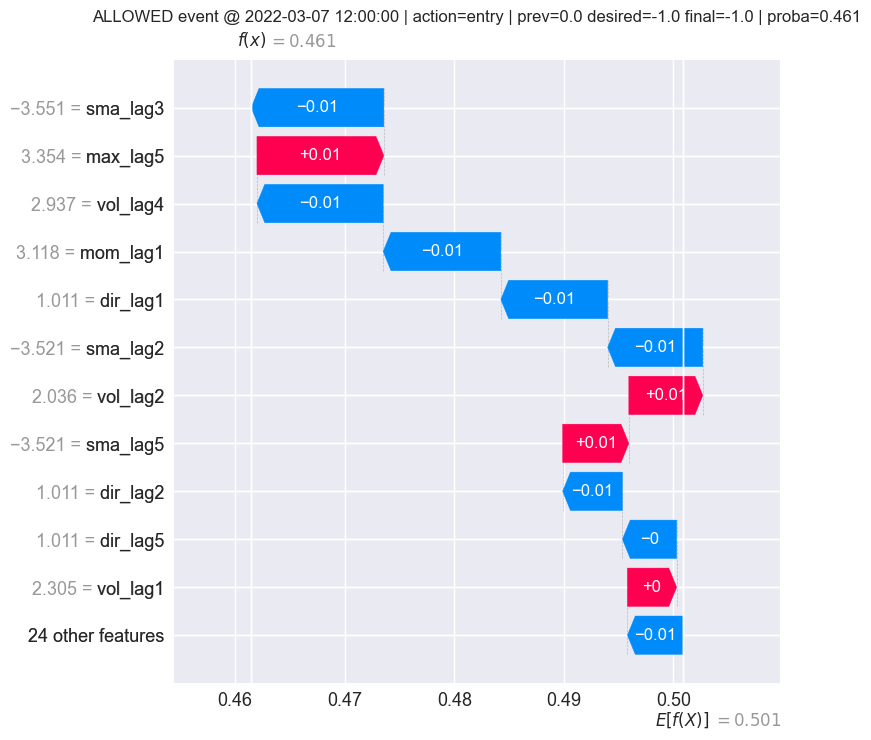


--- Explanation (ALLOWED entry/flip) ---
prev=0.0, desired=-1.0, final=-1.0
proba=0.461, shap_sum=-0.0394, top1_abs=0.0121
shap_threshold=0.0106
top features: sma_lag3(-0.0121), max_lag5(+0.0116), vol_lag4(-0.0115)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW


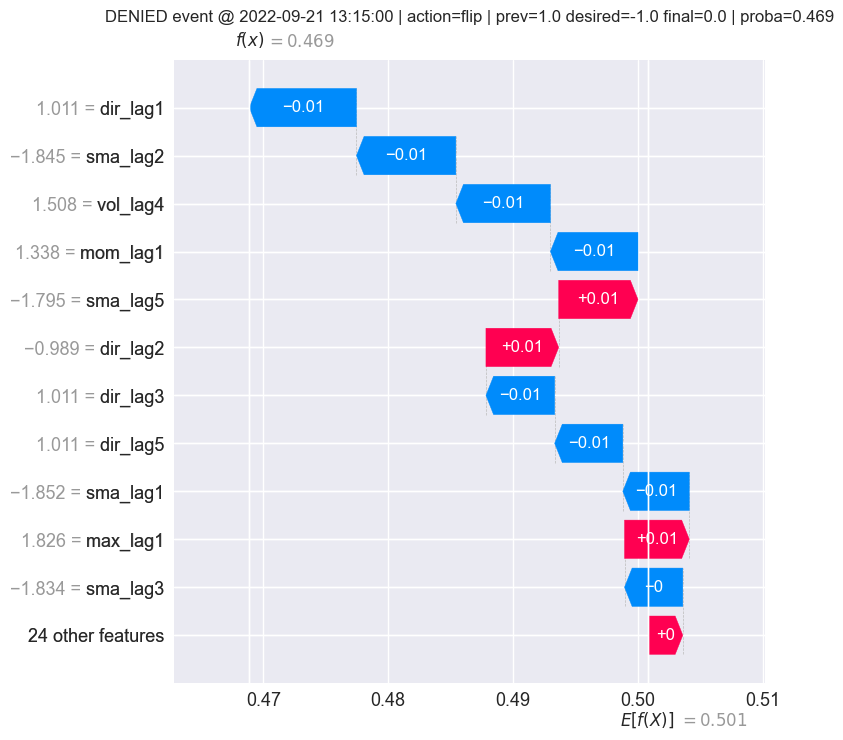


--- Explanation (DENIED entry/flip) ---
prev=1.0, desired=-1.0, final=0.0
proba=0.469, shap_sum=-0.0320, top1_abs=0.0086
shap_threshold=0.0106
top features: dir_lag1(-0.0086), sma_lag2(-0.0080), vol_lag4(-0.0076)
checks: proba=True direction=True magnitude=False top1_ok=False
DECISION: DENY


In [52]:
# Waterfall plots: one random ALLOWED entry/flip and one random DENIED entry/flip

def _get_expected_value(exp):
    ev = getattr(exp, "expected_value", 0.0)
    if isinstance(ev, (list, tuple, np.ndarray)):
        ev = ev[0]
    return float(np.array(ev).reshape(()))


def waterfall_for_event(event_time, label):
    x = test_s.loc[event_time, col].values
    shap_values = explainer.shap_values(x.reshape(1, -1), check_additivity=False)
    sv = _extract_shap_vector(shap_values)
    base = _get_expected_value(explainer)

    exp = shap.Explanation(
        values=sv,
        base_values=base,
        data=x,
        feature_names=col,
    )

    meta = gate_log_df.loc[event_time]
    title = (
        f"{label} event @ {event_time} | action={meta['action']} | "
        f"prev={meta['prev_pos']} desired={meta['desired_pos']} final={meta['final_pos']} | proba={meta['proba']:.3f}"
    )

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, max_display=12, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(42)

# We want cases where the gate actually matters: entries or flips (not exits)
entry_like = gate_log_df["action"].isin(["entry", "flip"]) & (gate_log_df["desired_pos"].astype(float) != 0)

allowed_candidates = gate_log_df[entry_like & (gate_log_df["allow"])].index

denied_candidates = gate_log_df[entry_like & (~gate_log_df["allow"])].index

if len(allowed_candidates) > 0:
    t_allowed = allowed_candidates[rng.integers(0, len(allowed_candidates))]
    waterfall_for_event(t_allowed, "ALLOWED")
    print("\n--- Explanation (ALLOWED entry/flip) ---")
    print(gate_log_df.loc[t_allowed, "explanation"])
else:
    print("No ALLOWED entry/flip events available to plot.")

if len(denied_candidates) > 0:
    t_denied = denied_candidates[rng.integers(0, len(denied_candidates))]
    waterfall_for_event(t_denied, "DENIED")
    print("\n--- Explanation (DENIED entry/flip) ---")
    print(gate_log_df.loc[t_denied, "explanation"])
else:
    print("No DENIED entry/flip events available to plot.")

## Additional XAI Visualisations (MSc-ready)

This block produces four groups of figures:

1) **Global feature importance** (SHAP beeswarm + bar)
2) **Local explanations** (already shown above via waterfall plots)
3) **Gate behavior summary** (allowed vs denied distributions + top-driver frequency)
4) **Regime / time stability** (rolling mean absolute SHAP for top features)

Notes:
- SHAP for deep models is compute-heavy. These cells intentionally compute SHAP on a **sample** to keep runtime practical.
- To make results reproducible, a fixed RNG seed is used for sampling.

In [53]:
# ---- SHAP sampling utilities (used by multiple plots) ----

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Control how many points to explain (trade-off: quality vs runtime)
GLOBAL_SHAP_SAMPLES = 1200      # for global beeswarm+bar
REGIME_SHAP_SAMPLES = 2000      # for rolling stability
SHAP_BATCH = 200                # batch size for explainer

# Choose where to sample from:
# - For "global" interpretation across all timestamps, sample from test_s.
# - For "trade-centric" interpretation, sample from trade events only.
USE_TRADE_EVENTS_FOR_GLOBAL = False


def _extract_shap_matrix(shap_values):
    """Return a (n_samples, n_features) matrix from DeepExplainer output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr)


def compute_shap_for_index(index, *, batch_size=SHAP_BATCH):
    """
    Compute SHAP values for rows in `index` using `test_s[col]` and the global `explainer`.
    Returns: X (n, d), S (n, d)
    """
    X = test_s.loc[index, col].values
    S_chunks = []

    for start in range(0, len(index), batch_size):
        end = min(start + batch_size, len(index))
        xb = X[start:end]
        sv = explainer.shap_values(xb, check_additivity=False)
        S_chunks.append(_extract_shap_matrix(sv))

    S = np.vstack(S_chunks) if len(S_chunks) else np.empty((0, len(col)))
    return X, S


def _sample_index_from_pool(pool_index, n):
    pool_index = np.array(pool_index)
    if len(pool_index) <= n:
        return pool_index
    take = rng.choice(len(pool_index), size=n, replace=False)
    return pool_index[take]


# Build sampling pools
trade_event_idx = gate_log_df.index  # when the baseline strategy changed position
all_test_idx = test.index

global_pool = trade_event_idx if USE_TRADE_EVENTS_FOR_GLOBAL else all_test_idx

# Samples for plots
idx_global = _sample_index_from_pool(global_pool, GLOBAL_SHAP_SAMPLES)
idx_regime = _sample_index_from_pool(trade_event_idx, REGIME_SHAP_SAMPLES)

print("Global SHAP sample size:", len(idx_global), "(trade-centric:" , USE_TRADE_EVENTS_FOR_GLOBAL, ")")
print("Regime SHAP sample size:", len(idx_regime), "(trade-event-only)")

Global SHAP sample size: 1200 (trade-centric: False )
Regime SHAP sample size: 546 (trade-event-only)


In [54]:
model

<Sequential name=sequential, built=True>

In [55]:
mu

price        1.16220
spread       0.00016
returns      0.00000
dir          0.49462
sma          0.00001
boll         0.00984
min         -0.00195
max          0.00191
mom          0.00000
vol          0.00040
sma_lag1     0.00001
sma_lag2     0.00001
sma_lag3     0.00001
sma_lag4     0.00001
sma_lag5     0.00001
boll_lag1    0.00979
boll_lag2    0.00975
boll_lag3    0.00970
boll_lag4    0.00966
boll_lag5    0.00963
min_lag1    -0.00195
min_lag2    -0.00195
min_lag3    -0.00195
min_lag4    -0.00195
min_lag5    -0.00195
max_lag1     0.00191
max_lag2     0.00191
max_lag3     0.00191
max_lag4     0.00191
max_lag5     0.00191
mom_lag1     0.00000
mom_lag2     0.00000
mom_lag3     0.00000
mom_lag4     0.00000
mom_lag5     0.00000
vol_lag1     0.00040
vol_lag2     0.00040
vol_lag3     0.00040
vol_lag4     0.00040
vol_lag5     0.00040
dir_lag1     0.49462
dir_lag2     0.49462
dir_lag3     0.49462
dir_lag4     0.49460
dir_lag5     0.49462
dtype: float64

In [56]:
std

price       0.04247
spread      0.00010
returns     0.00045
dir         0.49998
sma         0.00226
boll        1.41770
min         0.00196
max         0.00204
mom         0.00026
vol         0.00021
sma_lag1    0.00226
sma_lag2    0.00226
sma_lag3    0.00226
sma_lag4    0.00226
sma_lag5    0.00226
boll_lag1   1.41772
boll_lag2   1.41772
boll_lag3   1.41773
boll_lag4   1.41773
boll_lag5   1.41773
min_lag1    0.00196
min_lag2    0.00196
min_lag3    0.00196
min_lag4    0.00196
min_lag5    0.00196
max_lag1    0.00204
max_lag2    0.00204
max_lag3    0.00204
max_lag4    0.00204
max_lag5    0.00204
mom_lag1    0.00026
mom_lag2    0.00026
mom_lag3    0.00026
mom_lag4    0.00026
mom_lag5    0.00026
vol_lag1    0.00021
vol_lag2    0.00021
vol_lag3    0.00021
vol_lag4    0.00021
vol_lag5    0.00021
dir_lag1    0.49998
dir_lag2    0.49998
dir_lag3    0.49998
dir_lag4    0.49998
dir_lag5    0.49998
dtype: float64

In [57]:
model.save("DNN_model.keras")

In [58]:
import pickle

In [59]:
params = {"mu":mu, "std":std}

In [60]:
params

{'mu': price        1.16220
 spread       0.00016
 returns      0.00000
 dir          0.49462
 sma          0.00001
 boll         0.00984
 min         -0.00195
 max          0.00191
 mom          0.00000
 vol          0.00040
 sma_lag1     0.00001
 sma_lag2     0.00001
 sma_lag3     0.00001
 sma_lag4     0.00001
 sma_lag5     0.00001
 boll_lag1    0.00979
 boll_lag2    0.00975
 boll_lag3    0.00970
 boll_lag4    0.00966
 boll_lag5    0.00963
 min_lag1    -0.00195
 min_lag2    -0.00195
 min_lag3    -0.00195
 min_lag4    -0.00195
 min_lag5    -0.00195
 max_lag1     0.00191
 max_lag2     0.00191
 max_lag3     0.00191
 max_lag4     0.00191
 max_lag5     0.00191
 mom_lag1     0.00000
 mom_lag2     0.00000
 mom_lag3     0.00000
 mom_lag4     0.00000
 mom_lag5     0.00000
 vol_lag1     0.00040
 vol_lag2     0.00040
 vol_lag3     0.00040
 vol_lag4     0.00040
 vol_lag5     0.00040
 dir_lag1     0.49462
 dir_lag2     0.49462
 dir_lag3     0.49462
 dir_lag4     0.49460
 dir_lag5     0.49462
 dty

In [61]:
pickle.dump(params, open("params.pkl", "wb"))

In [62]:
summary = pd.DataFrame(
    {
        "ending_value_net": [
            float(test["cstrategy_net"].iloc[-1]),
            float(test["cstrategy_net_xai"].iloc[-1]),
        ],
        "orders_sum_abs_pos_change": [
            float(test["trades"].fillna(0).sum()),
            float(test["trades_xai"].fillna(0).sum()),
        ],
        "trade_event_bars": [
            int((test["trades"].fillna(0) > 0).sum()),
            int((test["trades_xai"].fillna(0) > 0).sum()),
        ],
        # Better cost reporting:
        "total_trade_cost_paid": [
            float((test["trades"].fillna(0) * ptc).sum()),
            float((test["trades_xai"].fillna(0) * ptc).sum()),
        ],
    },
    index=["baseline", "xai_gated"],
)

summary["avg_cost_per_trade_event"] = (
    summary["total_trade_cost_paid"] / summary["trade_event_bars"].replace(0, np.nan)
)

summary["avg_cost_per_order_unit"] = (
    summary["total_trade_cost_paid"] / summary["orders_sum_abs_pos_change"].replace(0, np.nan)
)

summary["order_reduction_vs_baseline"] = np.nan
summary.loc["xai_gated", "order_reduction_vs_baseline"] = (
    1 - summary.loc["xai_gated", "orders_sum_abs_pos_change"] / summary.loc["baseline", "orders_sum_abs_pos_change"]
)

summary

,ending_value_net,orders_sum_abs_pos_change,trade_event_bars,total_trade_cost_paid,avg_cost_per_trade_event,avg_cost_per_order_unit,order_reduction_vs_baseline
baseline,0.89640,634.00000,546,0.03170,0.00006,0.00005,NaN
xai_gated,0.94117,426.00000,390,0.02130,0.00005,0.00005,0.32808


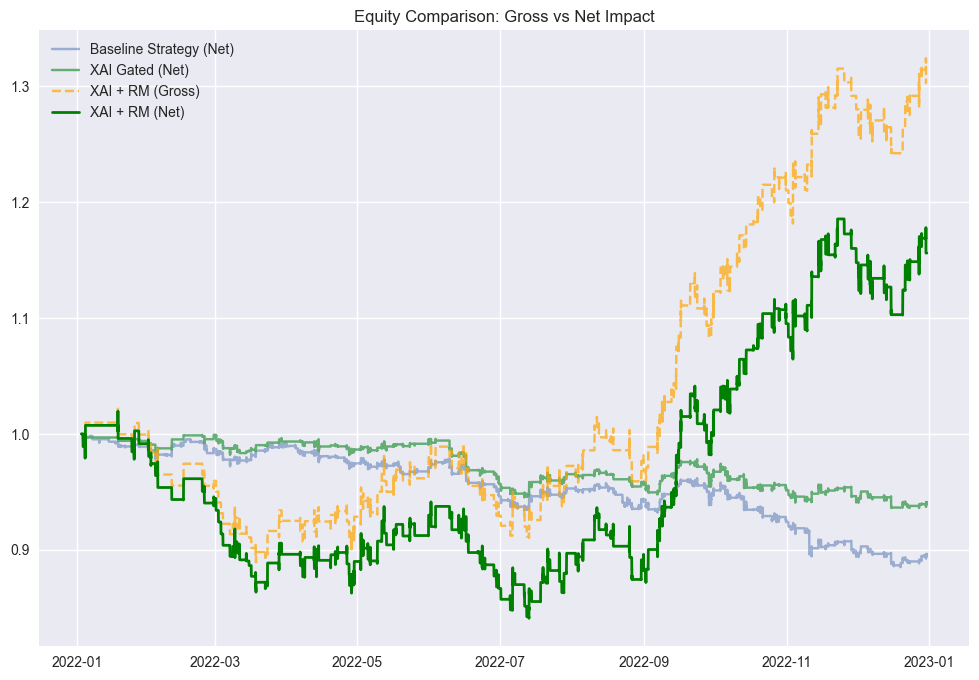


--- Risk Management System Performance ---
Initial Capital:          100000
Final Capital (Gross):    130274.63
Final Capital (Net):      115606.46
Total Transaction Costs:  14668.17
Total Trades:             213
Win Rate:                 45.07%
Avg Win (Net):            $1224.09
Avg Loss (Net):           $-870.99
Profit Factor:            1.15


In [63]:

# -------------------------------------------------------------------------------------
# RISK MANAGEMENT SYSTEM IMPLEMENTATION (OPTIMIZED & ROBUST)
# -------------------------------------------------------------------------------------
# Logic:
# 1. Capital: 100,000
# 2. Risk per Trade: 1% of Capital
# 3. Position Sizing: Risk Amount / (Entry - SL)
# 4. Target: 1:2 Risk:Reward Ratio
# 5. Stop Loss: Dynamic based on Volatility (2 * Volatility * Price)
# 6. Transaction Costs: 0.00005 (paid on both Entry and Exit volume)

INITIAL_CAPITAL = 100000
RISK_PCT = 0.01
REWARD_RATIO = 2.0
LEVERAGE_CAP = 30 # Safety cap
PTC = 0.00005 # Cost per unit of value traded (matches 'ptc' in cells above)

class RiskManagedBacktest:
    def __init__(self, df, signal_col="position_xai", price_col="price", vol_col="vol"):
        self.df = df
        self.signal_col = signal_col
        self.price_col = price_col
        self.vol_col = vol_col
        
        # Net Capital (With Costs)
        self.capital = INITIAL_CAPITAL
        self.equity = [INITIAL_CAPITAL]
        
        # Gross Capital (Without Costs) - For Comparison
        self.capital_gross = INITIAL_CAPITAL
        self.equity_gross = [INITIAL_CAPITAL]
        
        self.trades_list = []
        
    def run(self):
        # OPTIMIZATION: Convert columns to Numpy arrays before looping to prevent Kernel Crash
        # Looping 25k times with .iloc causes high memory churn
        price_arr = self.df[self.price_col].values
        vol_arr = self.df[self.vol_col].values
        signal_arr = self.df[self.signal_col].values
        index_arr = self.df.index
        
        # State
        position = 0 # 0, 1, -1
        entry_price = 0.0
        stop_loss = 0.0
        take_profit = 0.0
        qty = 0
        entry_time = index_arr[0] # Initialize for safety
        
        # Start loop
        for i in range(1, len(self.df)):
            idx = index_arr[i]
            
            # Current Market Data via Numpy (Fast)
            current_price = price_arr[i]
            current_vol = vol_arr[i]
            current_signal = signal_arr[i]
            prev_signal = signal_arr[i-1]
            
            # 1. MANAGE EXISTING TRADE (SL/TP)
            if position != 0:
                # Check for SL Hit (Assume hit at SL level exactly)
                sl_hit = (position == 1 and current_price <= stop_loss) or \
                         (position == -1 and current_price >= stop_loss)
                
                # Check for TP Hit (Assume hit at TP level exactly)
                tp_hit = (position == 1 and current_price >= take_profit) or \
                         (position == -1 and current_price <= take_profit)
                
                # Check for Signal Exit (XAI Gate says Close or Flip)
                # If signal becomes 0 (Neutral) or flips sign against us
                sig_exit = (current_signal == 0) or (current_signal != position)
                
                exit_price = None
                exit_reason = None
                
                if sl_hit:
                    exit_price = stop_loss
                    exit_reason = "SL"
                elif tp_hit:
                    exit_price = take_profit
                    exit_reason = "TP"
                elif sig_exit:
                    exit_price = current_price
                    exit_reason = "Signal"
                
                if exit_price is not None:
                    # --- EXECUTION & COST CALCULATION ---
                    # 1. Gross PnL
                    trade_pnl = (exit_price - entry_price) * qty * position
                    
                    # 2. Transaction Costs
                    # Paid on Notional Value at Entry + Notional Value at Exit
                    cost_entry = abs(qty * entry_price * PTC)
                    cost_exit = abs(qty * exit_price * PTC)
                    classes_comm = cost_entry + cost_exit
                    
                    # 3. Net PnL
                    net_pnl = trade_pnl - classes_comm
                    
                    # Update Capitals
                    self.capital += net_pnl
                    self.capital_gross += trade_pnl
                    
                    self.trades_list.append({
                        "Entry Time": entry_time,
                        "Exit Time": idx,
                        "Type": "Long" if position == 1 else "Short",
                        "Entry Price": entry_price,
                        "Exit Price": exit_price,
                        "Reason": exit_reason,
                        "Qty": qty,
                        "Gross PnL": trade_pnl, # ADDED
                        "Comm": classes_comm,
                        "PnL": net_pnl,
                        "Return %": (net_pnl / (qty * entry_price) * 100) if qty > 0 else 0
                    })
                    
                    # Reset State
                    position = 0
                    qty = 0
            
            # 2. CHECK FOR NEW ENTRY (Only if Flat)
            if position == 0:
                # We only enter on a NEW signal (Edge Triggered)
                if current_signal != 0 and current_signal != prev_signal:
                    
                    # Risk Capital Allocation
                    risk_amt = self.capital * RISK_PCT
                    
                    # Filter: Minimum volatility for safety (avoid zero division)
                    eff_vol = max(current_vol, 0.0001)

                    # Dynamic Stop Distance (2 * Volatility * Price)
                    sl_dist = current_price * eff_vol * 2.0
                    
                    # Min Stop Distance Floor (e.g. 5 pips to avoid noise wicks)
                    min_dist = current_price * 0.0005
                    sl_dist = max(sl_dist, min_dist)
                        
                    if current_signal == 1: # Long
                        stop_loss = current_price - sl_dist
                        take_profit = current_price + (sl_dist * REWARD_RATIO)
                    else: # Short (Signal -1)
                        stop_loss = current_price + sl_dist
                        take_profit = current_price - (sl_dist * REWARD_RATIO)
                        
                    # Position Sizing: Quantity = Risk / Distance
                    if sl_dist > 0:
                        qty = risk_amt / sl_dist
                    else:
                        qty = 0
                        
                    # Cap Leverage to avoid excessive exposure
                    notional = qty * current_price
                    if notional > (self.capital * LEVERAGE_CAP):
                        qty = (self.capital * LEVERAGE_CAP) / current_price
                        
                    position = current_signal
                    entry_price = current_price
                    entry_time = idx
            
            # Record Equity (Mark-To-Market)
            open_pnl_gross = 0
            open_pnl_net = 0
            
            if position != 0:
                # Gross Open PnL
                open_pnl_gross = (current_price - entry_price) * qty * position
                
                # Net Open PnL (Subtract accrued entry cost)
                open_pnl_net = open_pnl_gross - (qty * entry_price * PTC)
            
            self.equity.append(self.capital + open_pnl_net)
            self.equity_gross.append(self.capital_gross + open_pnl_gross)
            
        return pd.DataFrame({
            'equity_net': self.equity,
            'equity_gross': self.equity_gross
        }, index=self.df.index[len(self.df)-len(self.equity):])

# Run the RM Backtest
rm_backtest = RiskManagedBacktest(test, signal_col="position_xai")
results_df = rm_backtest.run()
test['equity_rm'] = results_df['equity_net']
test['equity_rm_gross'] = results_df['equity_gross']

# Normalize for comparison plot
test['cstrategy_rm_norm'] = test['equity_rm'] / INITIAL_CAPITAL
test['cstrategy_rm_gross_norm'] = test['equity_rm_gross'] / INITIAL_CAPITAL

# Plotting Comparison
plt.figure(figsize=(12, 8))
plt.plot(test['cstrategy_net'], label='Baseline Strategy (Net)', alpha=0.5)
plt.plot(test['cstrategy_net_xai'], label='XAI Gated (Net)', alpha=0.9)
plt.plot(test['cstrategy_rm_gross_norm'], label='XAI + RM (Gross)', color='orange', linestyle='--', alpha=0.7)
plt.plot(test['cstrategy_rm_norm'], label='XAI + RM (Net)', color='green', linewidth=2)
plt.title("Equity Comparison: Gross vs Net Impact")
plt.legend()
plt.show()

# Statistics Report
trades_df = pd.DataFrame(rm_backtest.trades_list)
print("\n--- Risk Management System Performance ---")
print(f"Initial Capital:          {INITIAL_CAPITAL}")
print(f"Final Capital (Gross):    {test['equity_rm_gross'].iloc[-1]:.2f}")
print(f"Final Capital (Net):      {test['equity_rm'].iloc[-1]:.2f}")

impact = test['equity_rm_gross'].iloc[-1] - test['equity_rm'].iloc[-1]
print(f"Total Transaction Costs:  {impact:.2f}")
print(f"Total Trades:             {len(trades_df)}")

if len(trades_df) > 0:
    win_rate = len(trades_df[trades_df['PnL'] > 0]) / len(trades_df)
    avg_win = trades_df[trades_df['PnL'] > 0]['PnL'].mean()
    avg_loss = trades_df[trades_df['PnL'] <= 0]['PnL'].mean()
    
    print(f"Win Rate:                 {win_rate:.2%}")
    print(f"Avg Win (Net):            ${avg_win:.2f}")
    print(f"Avg Loss (Net):           ${avg_loss:.2f}")
    if avg_loss != 0:
        print(f"Profit Factor:            {abs(trades_df[trades_df['PnL']>0]['PnL'].sum() / trades_df[trades_df['PnL']<=0]['PnL'].sum()):.2f}")
else:
    print("No trades generated.")
